In [4]:
# Importing basic libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.metrics import accuracy_score, roc_auc_score, r2_score
from sklearn.tree import DecisionTreeRegressor

# 1. Loading dataset, handling duplicates and missing values, and splitting


In [3]:
pip install ucimlrepo

In [5]:
from ucimlrepo import fetch_ucirepo

# fetching dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

# data (as pandas dataframes)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets

# metadata
print(concrete_compressive_strength.metadata)

# variable information
print(concrete_compressive_strength.variables)


{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

In [6]:
df = pd.concat([X, y], axis=1)
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 25


In [7]:
df = df.drop_duplicates()
print(f"Shape of DataFrame after removing duplicates: {df.shape}")

Shape of DataFrame after removing duplicates: (1005, 9)


In [8]:
missing_values_count = df.isnull().sum()
print("Number of missing values per column:")
print(missing_values_count)

Number of missing values per column:
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    0
dtype: int64


In [9]:
# Splitting data into training (70%) and temporary (30%) sets
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42)

# Splitting the temporary set into validation (15%) and test (15%) sets
# Since temp is 30% of the original data, 15% of original data is 50% of temp data
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Training set shape: {df_train.shape}")
print(f"Validation set shape: {df_val.shape}")
print(f"Test set shape: {df_test.shape}")

Training set shape: (703, 9)
Validation set shape: (151, 9)
Test set shape: (151, 9)


# 2. Implementing adaboost regressor

In [10]:
epsilon = 1e-10

In [11]:
class AdaboostR2:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.regressors = []
        self.alphas = []

    def fit(self, X_train, y_train):
        n_samples = X_train.shape[0]
        D = np.full(n_samples, 1.0 / n_samples)

        for _ in range(self.n_estimators):
            # Training weak regressor
            regressor = DecisionTreeRegressor(max_depth=1)
            regressor.fit(X_train, y_train, sample_weight=D)
            predictions = regressor.predict(X_train)

            # Calculating error and loss
            abs_error = np.abs(y_train - predictions)
            max_abs_error = np.max(abs_error)
            loss = abs_error / (max_abs_error + epsilon)

            # Calculating regressor weight (alpha)
            average_loss = np.sum(D * loss)
            alpha = average_loss / (1 - average_loss + epsilon)

            # Updating instance weights
            D = D * np.power(alpha, 1 - loss)
            D = D / np.sum(D)  # Normalizing weights

            # Storing regressor and alpha
            self.regressors.append(regressor)
            self.alphas.append(alpha)

    def predict(self, X_test):
        predictions = np.zeros((X_test.shape[0], self.n_estimators))
        for i, regressor in enumerate(self.regressors):
            predictions[:, i] = regressor.predict(X_test)

        # Weighted median prediction
        sorted_idx = np.argsort(predictions, axis=1)
        sorted_predictions = np.take_along_axis(predictions, sorted_idx, axis=1)
        sorted_alphas = np.take_along_axis(np.array(self.alphas).reshape(1, -1), sorted_idx, axis=1)

        cumulative_alpha = np.cumsum(sorted_alphas, axis=1)
        median_alpha = np.sum(self.alphas) / 2.0

        # Finding the index where the cumulative alpha exceeds the median alpha
        median_idx = np.argmax(cumulative_alpha >= median_alpha, axis=1)

        # Getting the weighted median prediction
        final_predictions = np.take_along_axis(sorted_predictions, median_idx.reshape(-1, 1), axis=1).flatten()

        return final_predictions


In [12]:
X_train = df_train.drop('Concrete compressive strength', axis=1)
y_train = df_train['Concrete compressive strength']
X_val = df_val.drop('Concrete compressive strength', axis=1)
y_val = df_val['Concrete compressive strength']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (703, 8)
y_train shape: (703,)
X_val shape: (151, 8)
y_val shape: (151,)


# 3. Evaluating adaboost.r2 for different m




In [13]:
m_values = [5, 10, 20, 40, 60, 80, 100, 150, 200, 500, 1000, 5000, 10000]
r2_scores = []

for m in m_values:
    adaboost_r2 = AdaboostR2(n_estimators=m)
    adaboost_r2.fit(X_train, y_train)
    predictions = adaboost_r2.predict(X_val)
    r2 = r2_score(y_val, predictions)
    r2_scores.append(r2)

print("R^2 scores for different M values:", r2_scores)

R^2 scores for different M values: [0.4502090854802536, 0.5361301673634689, 0.4902164170000701, 0.44290591780892186, 0.45442825552980837, 0.4193731825805965, 0.3941356591612172, 0.2278942683003834, 0.036889283904555814, -0.014958013054689578, -0.014958013054689578, -0.014958013054692909, -0.014958013054695574]


## Plotting r^2 vs. m



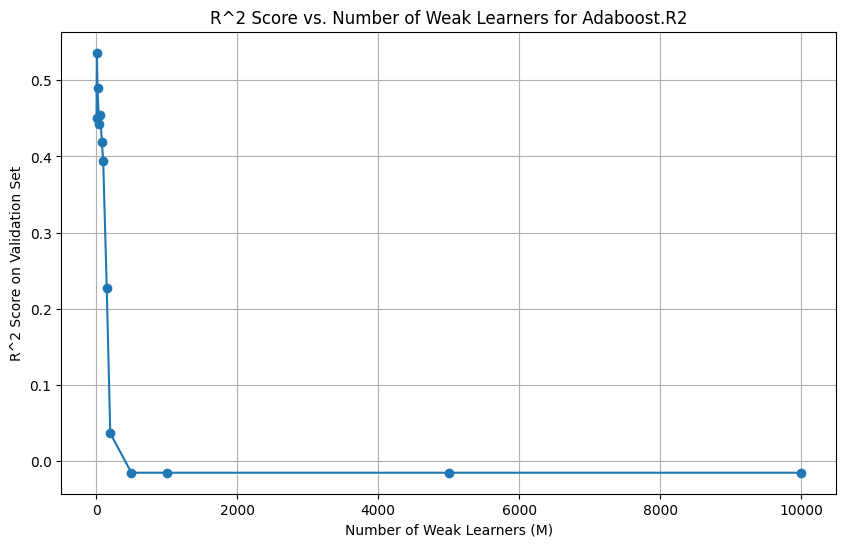

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(m_values, r2_scores, marker='o')
plt.xlabel("Number of Weak Learners (M)")
plt.ylabel("R^2 Score on Validation Set")
plt.title("R^2 Score vs. Number of Weak Learners for Adaboost.R2")
plt.grid(True)
plt.show()

## Choose suitable m = 10



In [15]:
X_test = df_test.drop('Concrete compressive strength', axis=1)
y_test = df_test['Concrete compressive strength']

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (151, 8)
y_test shape: (151,)


## Training adaboost.r2 with optimal m




In [16]:
best_m = 10
adaboost_final = AdaboostR2(n_estimators=best_m)
adaboost_final.fit(X_train, y_train)

#4. Predicting on test set




In [17]:
test_predictions = adaboost_final.predict(X_test)

In [18]:
# R2 score
r2_test = r2_score(y_test, test_predictions)
print(f"R^2 score on the test set: {r2_test}")

R^2 score on the test set: 0.4473870577121999


## Plotting predictions vs. ground truths



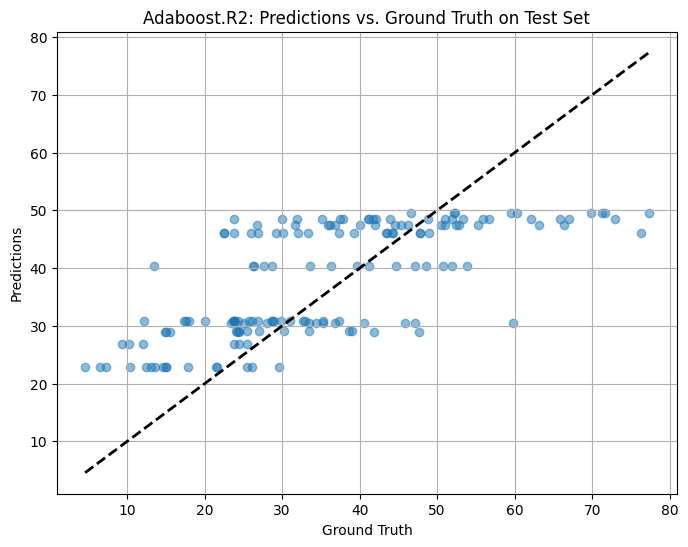

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_predictions, alpha=0.5)
plt.xlabel("Ground Truth")
plt.ylabel("Predictions")
plt.title("Adaboost.R2: Predictions vs. Ground Truth on Test Set")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line for reference
plt.grid(True)
plt.show()

# 5. Using scikit-learn's AdaboostRegressor

In [20]:
from sklearn.ensemble import AdaBoostRegressor

In [21]:
adaboost_sklearn = AdaBoostRegressor(n_estimators=best_m, random_state=42)
adaboost_sklearn.fit(X_train, y_train)

AdaBoostRegressor(n_estimators=10, random_state=42)

# 6. Performing prediction on the test set using scikit-learn's AdaboostRegressor

In [22]:
test_predictions_sklearn = adaboost_sklearn.predict(X_test)

In [23]:
# R2 score
r2_test_sklearn = r2_score(y_test, test_predictions_sklearn)
print(f"R^2 score on the test set (scikit-learn): {r2_test_sklearn}")

R^2 score on the test set (scikit-learn): 0.7078344599461415


## Plotting predictions vs. ground truths




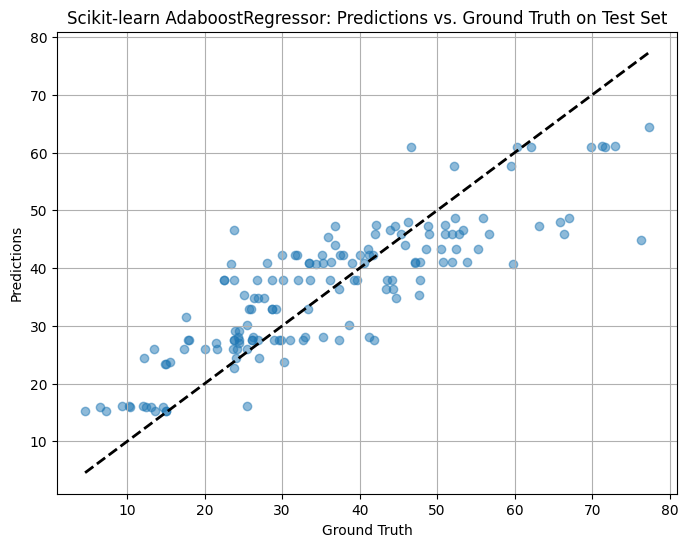

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_predictions_sklearn, alpha=0.5)
plt.xlabel("Ground Truth")
plt.ylabel("Predictions")
plt.title("Scikit-learn AdaboostRegressor: Predictions vs. Ground Truth on Test Set")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.grid(True)
plt.show()

# 7. Comparison of Adaboost Regressor Implementations



- **From scratch implementation:** R^2 score on the test set: 0.447
- **Scikit-learn implementation:** R^2 score on the test set: 0.708

The scikit-learn implementation (R^2 = 0.708) performs significantly better than the from-scratch implementation (R^2 = 0.447).